In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Audio, display
from pynwb import NWBHDF5IO

import ipywidgets as widgets
from ipywidgets import interact, interactive, fixed, IntSlider, FloatSlider, Dropdown, Checkbox

from brain_audio_decoder import BrainAudioDecoder
from custom_decoder import CustomBrainAudioDecoder
from brain_audio_decoder_viz import BrainAudioDecoderViz
from acoustic_change_detector import AcousticChangeDetector
from phoneme_validator import PhonemeValidator
from phoneme_model import PhonemeDecoderModel
from phonetic_dictionary import PhoneticDictionary

In [2]:
# Define paths
path_bids = './SingleWordProductionDutch-iBIDS'  # Path to the BIDS dataset
path_output = './features'  # Path to save extracted features
path_results = './results'  # Path to save results

In [3]:
# This decoder extends the baseline BrainAudioDecoder with additional functionality
# for phoneme-level analysis and provides stratification capabilities for participants.
custom_decoder = CustomBrainAudioDecoder(
    path_bids=path_bids,      # Path to the BIDS-formatted dataset
    path_output=path_output,  # Path to save extracted features
    path_results=path_results # Path to save results and visualizations
)
custom_decoder.enable_debug() # Enable detailed logging for troubleshooting

CustomBrainAudioDecoder: Initializing CustomBrainAudioDecoder with debug_mode=False
CustomBrainAudioDecoder: Debug mode enabled


In [4]:
# This loads metadata for all participants and extracts high gamma features
# from the EEG data, which will be used for model training.
custom_decoder.load_participants()
custom_decoder.extract_features_all_participants()

# This identifies which channels are most relevant for speech decoding
# and will be used to stratify participants by signal quality.
custom_decoder.analyze_channels_across_participants()

Found 10 participants:
  1. sub-01
  2. sub-02
  3. sub-03
  4. sub-04
  5. sub-05
  6. sub-06
  7. sub-07
  8. sub-08
  9. sub-09
  10. sub-10
Extracting features for sub-01...
Extracting features for sub-02...
Extracting features for sub-03...
Extracting features for sub-04...
Extracting features for sub-05...
Extracting features for sub-06...
Extracting features for sub-07...
Extracting features for sub-08...
Extracting features for sub-09...
Extracting features for sub-10...
Analyzing channels across participants...

Analyzing sub-01...
Loading existing results for sub-01...

Analyzing sub-02...
Loading existing results for sub-02...

Analyzing sub-03...
Loading existing results for sub-03...

Analyzing sub-04...
Loading existing results for sub-04...

Analyzing sub-05...
Loading existing results for sub-05...

Analyzing sub-06...
Loading existing results for sub-06...

Analyzing sub-07...
Loading existing results for sub-07...

Analyzing sub-08...
Loading existing results for sub-

{'sub-01': {'LA1': {'correlation': 0.04148753333452151,
   'region': 'Left-Cerebral-White-Matter',
   'index': 0,
   'correlations_by_fold': array([[ 0.08394009,  0.07796735,  0.08899915,  0.10506899,  0.10643324,
            0.11347047,  0.11084663,  0.12216204,  0.0718188 ,  0.10921887,
            0.12796517,  0.11166413,  0.11494964,  0.10910039,  0.11195502,
            0.10776214,  0.10254293,  0.09298878,  0.08279124,  0.06506515,
            0.05911008,  0.06387643,  0.04397557],
          [-0.06357089, -0.0659276 , -0.07813055, -0.07606354, -0.0997465 ,
           -0.11010209, -0.10795719, -0.10517158, -0.10803587, -0.10056936,
           -0.10580493, -0.1035407 , -0.10226087, -0.1071615 , -0.107879  ,
           -0.10602132, -0.10578259, -0.11972009, -0.12518309, -0.12121532,
           -0.12849383, -0.12694488, -0.11717225],
          [ 0.10336479,  0.10583034,  0.10604898,  0.11196844,  0.12030556,
            0.12286169,  0.11416333,  0.10867079,  0.10916221,  0.11888269,


In [5]:
# Groups participants into high, medium, and low quality based on
# the strength of speech-related signals in their EEG data.
participant_strata = custom_decoder.stratify_participants_by_channel_quality(
    channel_correlation_threshold=0.1  # Minimum correlation for a channel to be considered relevant
)

CustomBrainAudioDecoder [DEBUG]: Stratifying participants based on channel quality...
CustomBrainAudioDecoder [DEBUG]: Analyzing channels for sub-01...
CustomBrainAudioDecoder [DEBUG]: Analyzing channels for sub-02...
CustomBrainAudioDecoder [DEBUG]: Analyzing channels for sub-03...
CustomBrainAudioDecoder [DEBUG]: Analyzing channels for sub-04...
CustomBrainAudioDecoder [DEBUG]: Analyzing channels for sub-05...
CustomBrainAudioDecoder [DEBUG]: Analyzing channels for sub-06...
CustomBrainAudioDecoder [DEBUG]: Analyzing channels for sub-07...
CustomBrainAudioDecoder [DEBUG]: Analyzing channels for sub-08...
CustomBrainAudioDecoder [DEBUG]: Analyzing channels for sub-09...
CustomBrainAudioDecoder [DEBUG]: Analyzing channels for sub-10...
CustomBrainAudioDecoder: 
Participant stratification results:
CustomBrainAudioDecoder:   Participants with most relevant channels: 3
CustomBrainAudioDecoder:   Participants with relevant channels: 4
CustomBrainAudioDecoder:   Participants with least rele

In [6]:
# # Call segment_data_by_words
# # Choose a participant to segment (e.g., sub-01)
# participant_id = 'sub-01'
# word_segments = custom_decoder.segment_data_by_words(
#     participant_id='sub-01',
#     pre_onset_ms=200,
#     post_offset_ms=200,
#     handle_overlaps='adjust'  # Options: 'adjust', 'flag', 'skip', 'allow'
# )

In [7]:
# Ensures that the training and test sets have similar distributions of
# participant quality and word frequencies for better generalization.

# contains both training and test splits, structured as
# split_result = {
#     'train': {participant_id: {word: [instance_indices], ...}, ...},
#     'test': {participant_id: {word: [instance_indices], ...}, ...},
#     'statistics': {...},
#     'word_segments_dict': {...}
# }
split_result = custom_decoder.create_stratified_cross_word_split(
    participant_strata=participant_strata,  # Participant quality strata
    test_ratio=0.2,                         # Proportion of data for testing
    min_word_freq=1,                        # Minimum word frequency to include
    random_seed=42                          # For reproducibility
)

CustomBrainAudioDecoder: Segmenting data for sub-06...
CustomBrainAudioDecoder [DEBUG]: Segmenting data by words for sub-06...
CustomBrainAudioDecoder [DEBUG]: Loaded 307594 word markers
CustomBrainAudioDecoder [DEBUG]: First 10 word markers: ['hoe' 'hoe' 'hoe' 'hoe' 'hoe' 'hoe' 'hoe' 'hoe' 'hoe' 'hoe']
CustomBrainAudioDecoder [DEBUG]: Found 100 word onsets
CustomBrainAudioDecoder [DEBUG]: First 5 word onsets: [(0, 'hoe'), (3077, 'zevenduizend'), (6152, 'en'), (9228, 'het'), (12302, 'smeekte')]
CustomBrainAudioDecoder [DEBUG]: Found 100 unique words with at least 1 occurrences
CustomBrainAudioDecoder [DEBUG]: Word 'hoe': 1 instances
CustomBrainAudioDecoder [DEBUG]: Word 'zevenduizend': 1 instances
CustomBrainAudioDecoder [DEBUG]: Word 'en': 1 instances
CustomBrainAudioDecoder [DEBUG]: Word 'het': 1 instances
CustomBrainAudioDecoder [DEBUG]: Word 'smeekte': 1 instances
CustomBrainAudioDecoder [DEBUG]: Word statistics:
CustomBrainAudioDecoder [DEBUG]:   Total unique words: 100
CustomBrai

CustomBrainAudioDecoder [DEBUG]: Loaded 307579 word markers
CustomBrainAudioDecoder [DEBUG]: First 10 word markers: ['de' 'de' 'de' 'de' 'de' 'de' 'de' 'de' 'de' 'de']
CustomBrainAudioDecoder [DEBUG]: Found 100 word onsets
CustomBrainAudioDecoder [DEBUG]: First 5 word onsets: [(0, 'de'), (3076, 'buurt'), (6153, 'verstijfde'), (9231, 'zonlicht'), (12307, 'zevenduizend')]
CustomBrainAudioDecoder [DEBUG]: Found 100 unique words with at least 1 occurrences
CustomBrainAudioDecoder [DEBUG]: Word 'de': 1 instances
CustomBrainAudioDecoder [DEBUG]: Word 'buurt': 1 instances
CustomBrainAudioDecoder [DEBUG]: Word 'verstijfde': 1 instances
CustomBrainAudioDecoder [DEBUG]: Word 'zonlicht': 1 instances
CustomBrainAudioDecoder [DEBUG]: Word 'zevenduizend': 1 instances
CustomBrainAudioDecoder [DEBUG]: Word statistics:
CustomBrainAudioDecoder [DEBUG]:   Total unique words: 100
CustomBrainAudioDecoder [DEBUG]:   Total word instances: 100
CustomBrainAudioDecoder [DEBUG]: 
Overlap statistics:
CustomBrainA

In [8]:
# # Get a batch of training data
train_batch = custom_decoder.get_data_batch(
    split_result=split_result,
    batch_type='train',
    participant_ids=None,  # Use all available participants
    max_instances_per_word=10,  # Limit instances per word for balance
    balanced_sampling=True,
    batch_size=32
)

In [9]:
# Prepare features for model training
model_data = custom_decoder.prepare_word_model_data(
    batch=train_batch,
    feature_extraction_method = 'multi_band', #'high_gamma', #'multi band'
    temporal_context=True,
    standardize=True,
    pca_components=50
)

print(f"Prepared {len(model_data['features'])} feature sets for model training")
print(f"Feature dimensions: {model_data['features'][0].shape}")

Prepared 32 feature sets for model training
Feature dimensions: (255, 50)


In [10]:
# This component is responsible for segmenting continuous speech signals
# into individual phonemes by detecting acoustic boundaries.
detector = AcousticChangeDetector(
    min_segment_duration=0.03,    # Minimum phoneme duration in seconds
    max_segment_duration=0.3,     # Maximum phoneme duration in seconds
    distance_metric='cosine',     # Method to measure acoustic change
    smoothing_window=3,           # Window for smoothing distance curve
    peak_threshold=0.5,           # Threshold for boundary detection
    decoder=custom_decoder,       # Reference to the custom decoder
    debug_mode=True               # Enable detailed logging
)

# This allows the detector to access the train/test split when accumulating phoneme data
detector.split_result = split_result

AcousticChangeDetector: Initialized with DEBUG_MODE=True
PhoneticDictionary: Initialized with DEBUG_MODE=False


In [11]:
# accumulated_data = detector.accumulate_phoneme_data(
#     num_batches=5,
#     batch_size=32,
#     feature_extraction_method='high_gamma'
# )

# print(f"Accumulated {accumulated_data['metadata']['n_phonemes']} phoneme segments")
# print(f"Found {accumulated_data['metadata']['unique_phonemes']} unique phonemes")

# converted_acc_data = {
#     'phoneme_labels': accumulated_data['phoneme_labels'],
#     'phoneme_spectrogram_segments': accumulated_data['spectrograms'] if accumulated_data['spectrograms'] is not None else [],
#     'phoneme_words': accumulated_data['phoneme_words'],
#     'phoneme_positions': [0] * len(accumulated_data['phoneme_labels']) if 'phoneme_positions' not in accumulated_data else accumulated_data['phoneme_positions'],
#     'phoneme_participant_ids': accumulated_data['phoneme_participant_ids'] if 'phoneme_participant_ids' in accumulated_data else ['unknown'] * len(accumulated_data['phoneme_labels'])
# }

In [12]:
# Processes multiple batches of data to build a comprehensive training set
# of phoneme segments with their corresponding EEG features
train = detector.accumulate_phoneme_data(
    num_batches=5,                         # Number of batches to process
    batch_size=32,                         # Instances per batch
    feature_extraction_method= 'multi_band' #'high_gamma' # Method for extracting EEG features
)
print(f"Accumulated {train['metadata']['n_phonemes']} training phoneme segments")
print(f"Found {train['metadata']['unique_phonemes']} unique phonemes")

AcousticChangeDetector: Accumulating train data from 5 batches...
AcousticChangeDetector: Processing batch 1/5
AcousticChangeDetector [DEBUG]: Processing batch with 32 instances
AcousticChangeDetector [DEBUG]: Original batch keys: ['eeg_segments', 'audio_segments', 'words', 'participant_ids', 'metadata', 'spectrogram_segments']
AcousticChangeDetector [DEBUG]: EEG segments in batch: True
AcousticChangeDetector [DEBUG]: Spectrogram segments in batch: True
AcousticChangeDetector [DEBUG]: Processing instance 0/32: tot
AcousticChangeDetector [DEBUG]: Added EEG segment with shape (3080, 127)
AcousticChangeDetector [DEBUG]: Detecting boundaries for word: tot
AcousticChangeDetector [DEBUG]: Estimated 3 phonemes for 'tot'
AcousticChangeDetector [DEBUG]: Added EEG segment with shape (3075, 127)
AcousticChangeDetector [DEBUG]: Detecting boundaries for word: mij
AcousticChangeDetector [DEBUG]: Estimated 2 phonemes for 'mij'
AcousticChangeDetector [DEBUG]: Added EEG segment with shape (3078, 122)
A

AcousticChangeDetector [DEBUG]: Processing segment 4 with shape (3074, 115)
AcousticChangeDetector [DEBUG]: Processing segment 5 with shape (3076, 54)
AcousticChangeDetector [DEBUG]: Processing segment 6 with shape (3079, 117)
AcousticChangeDetector [DEBUG]: Processing segment 7 with shape (3075, 127)
AcousticChangeDetector [DEBUG]: Processing segment 8 with shape (3077, 127)
AcousticChangeDetector [DEBUG]: Processing segment 9 with shape (3076, 60)
AcousticChangeDetector [DEBUG]: Processing segment 10 with shape (3073, 127)
AcousticChangeDetector [DEBUG]: Processing segment 11 with shape (3075, 127)
AcousticChangeDetector [DEBUG]: Processing segment 12 with shape (3076, 127)
AcousticChangeDetector [DEBUG]: Processing segment 13 with shape (3077, 117)
AcousticChangeDetector [DEBUG]: Processing segment 14 with shape (3078, 122)
AcousticChangeDetector [DEBUG]: Processing segment 15 with shape (3075, 127)
AcousticChangeDetector [DEBUG]: Processing segment 16 with shape (3076, 115)
Acousti

AcousticChangeDetector [DEBUG]: Processing segment 1 with shape (3079, 127)
AcousticChangeDetector [DEBUG]: Processing segment 2 with shape (3079, 122)
AcousticChangeDetector [DEBUG]: Processing segment 3 with shape (3076, 127)
AcousticChangeDetector [DEBUG]: Processing segment 4 with shape (3076, 115)
AcousticChangeDetector [DEBUG]: Processing segment 5 with shape (3081, 54)
AcousticChangeDetector [DEBUG]: Processing segment 6 with shape (3075, 117)
AcousticChangeDetector [DEBUG]: Processing segment 7 with shape (3077, 127)
AcousticChangeDetector [DEBUG]: Processing segment 8 with shape (3078, 127)
AcousticChangeDetector [DEBUG]: Processing segment 9 with shape (3073, 60)
AcousticChangeDetector [DEBUG]: Processing segment 10 with shape (3076, 127)
AcousticChangeDetector [DEBUG]: Processing segment 11 with shape (3077, 127)
AcousticChangeDetector [DEBUG]: Processing segment 12 with shape (3076, 127)
AcousticChangeDetector [DEBUG]: Processing segment 13 with shape (3077, 127)
AcousticCh

AcousticChangeDetector [DEBUG]: Processing segment 1 with shape (3077, 127)
AcousticChangeDetector [DEBUG]: Processing segment 2 with shape (3077, 122)
AcousticChangeDetector [DEBUG]: Processing segment 3 with shape (3074, 127)
AcousticChangeDetector [DEBUG]: Processing segment 4 with shape (3077, 115)
AcousticChangeDetector [DEBUG]: Processing segment 5 with shape (3075, 54)
AcousticChangeDetector [DEBUG]: Processing segment 6 with shape (3073, 117)
AcousticChangeDetector [DEBUG]: Processing segment 7 with shape (3072, 127)
AcousticChangeDetector [DEBUG]: Processing segment 8 with shape (3076, 127)
AcousticChangeDetector [DEBUG]: Processing segment 9 with shape (3074, 60)
AcousticChangeDetector [DEBUG]: Processing segment 10 with shape (3073, 127)
AcousticChangeDetector [DEBUG]: Processing segment 11 with shape (3073, 115)
AcousticChangeDetector [DEBUG]: Processing segment 12 with shape (3076, 127)
AcousticChangeDetector [DEBUG]: Processing segment 13 with shape (3074, 127)
AcousticCh

AcousticChangeDetector [DEBUG]: Processing segment 1 with shape (3073, 127)
AcousticChangeDetector [DEBUG]: Processing segment 2 with shape (3069, 122)
AcousticChangeDetector [DEBUG]: Processing segment 3 with shape (3076, 127)
AcousticChangeDetector [DEBUG]: Processing segment 4 with shape (3077, 115)
AcousticChangeDetector [DEBUG]: Processing segment 5 with shape (3077, 54)
AcousticChangeDetector [DEBUG]: Processing segment 6 with shape (3080, 117)
AcousticChangeDetector [DEBUG]: Processing segment 7 with shape (3072, 127)
AcousticChangeDetector [DEBUG]: Processing segment 8 with shape (3075, 127)
AcousticChangeDetector [DEBUG]: Processing segment 9 with shape (3075, 60)
AcousticChangeDetector [DEBUG]: Processing segment 10 with shape (3074, 54)
AcousticChangeDetector [DEBUG]: Processing segment 11 with shape (2647, 122)
AcousticChangeDetector [DEBUG]: Processing segment 12 with shape (3071, 115)
AcousticChangeDetector [DEBUG]: Processing segment 13 with shape (3076, 127)
AcousticCha

AcousticChangeDetector [DEBUG]: Processing segment 1 with shape (3074, 127)
AcousticChangeDetector [DEBUG]: Processing segment 2 with shape (3080, 122)
AcousticChangeDetector [DEBUG]: Processing segment 3 with shape (3077, 127)
AcousticChangeDetector [DEBUG]: Processing segment 4 with shape (3078, 115)
AcousticChangeDetector [DEBUG]: Processing segment 5 with shape (3081, 54)
AcousticChangeDetector [DEBUG]: Processing segment 6 with shape (3071, 117)
AcousticChangeDetector [DEBUG]: Processing segment 7 with shape (3074, 127)
AcousticChangeDetector [DEBUG]: Processing segment 8 with shape (3073, 127)
AcousticChangeDetector [DEBUG]: Processing segment 9 with shape (3075, 60)
AcousticChangeDetector [DEBUG]: Processing segment 10 with shape (3076, 60)
AcousticChangeDetector [DEBUG]: Processing segment 11 with shape (3077, 127)
AcousticChangeDetector [DEBUG]: Processing segment 12 with shape (3071, 115)
AcousticChangeDetector [DEBUG]: Processing segment 13 with shape (3077, 60)
AcousticChan

In [13]:
# Similar to training data accumulation but for the test set
test = detector.accumulate_phoneme_data(
    num_batches=3,                         # Fewer batches for test set
    batch_size=32,                         # Instances per batch
    feature_extraction_method= 'multi_band' #'high_gamma' # Same feature extraction method
)
print(f"Accumulated {test['metadata']['n_phonemes']} test phoneme segments")

AcousticChangeDetector: Accumulating train data from 3 batches...
AcousticChangeDetector: Processing batch 1/3
AcousticChangeDetector [DEBUG]: Processing batch with 32 instances
AcousticChangeDetector [DEBUG]: Original batch keys: ['eeg_segments', 'audio_segments', 'words', 'participant_ids', 'metadata', 'spectrogram_segments']
AcousticChangeDetector [DEBUG]: EEG segments in batch: True
AcousticChangeDetector [DEBUG]: Spectrogram segments in batch: True
AcousticChangeDetector [DEBUG]: Processing instance 0/32: wak
AcousticChangeDetector [DEBUG]: Added EEG segment with shape (3077, 127)
AcousticChangeDetector [DEBUG]: Detecting boundaries for word: wak
AcousticChangeDetector [DEBUG]: Estimated 2 phonemes for 'wak'
AcousticChangeDetector [DEBUG]: Added EEG segment with shape (3075, 127)
AcousticChangeDetector [DEBUG]: Detecting boundaries for word: smeekte
AcousticChangeDetector [DEBUG]: Estimated 6 phonemes for 'smeekte'
AcousticChangeDetector [DEBUG]: Mismatch for word 'smeekte': 6 pho

AcousticChangeDetector [DEBUG]: Processing segment 3 with shape (3077, 127)
AcousticChangeDetector [DEBUG]: Processing segment 4 with shape (3075, 115)
AcousticChangeDetector [DEBUG]: Processing segment 5 with shape (3073, 54)
AcousticChangeDetector [DEBUG]: Processing segment 6 with shape (3075, 117)
AcousticChangeDetector [DEBUG]: Processing segment 7 with shape (3073, 127)
AcousticChangeDetector [DEBUG]: Processing segment 8 with shape (3079, 127)
AcousticChangeDetector [DEBUG]: Processing segment 9 with shape (3075, 60)
AcousticChangeDetector [DEBUG]: Processing segment 10 with shape (3074, 54)
AcousticChangeDetector [DEBUG]: Processing segment 11 with shape (2647, 122)
AcousticChangeDetector [DEBUG]: Processing segment 12 with shape (3071, 115)
AcousticChangeDetector [DEBUG]: Processing segment 13 with shape (3077, 122)
AcousticChangeDetector [DEBUG]: Processing segment 14 with shape (3075, 127)
AcousticChangeDetector [DEBUG]: Processing segment 15 with shape (3076, 127)
AcousticC

AcousticChangeDetector [DEBUG]: Processing segment 1 with shape (3076, 127)
AcousticChangeDetector [DEBUG]: Processing segment 2 with shape (3079, 122)
AcousticChangeDetector [DEBUG]: Processing segment 3 with shape (3073, 127)
AcousticChangeDetector [DEBUG]: Processing segment 4 with shape (3078, 115)
AcousticChangeDetector [DEBUG]: Processing segment 5 with shape (3075, 54)
AcousticChangeDetector [DEBUG]: Processing segment 6 with shape (3077, 117)
AcousticChangeDetector [DEBUG]: Processing segment 7 with shape (3075, 127)
AcousticChangeDetector [DEBUG]: Processing segment 8 with shape (3075, 127)
AcousticChangeDetector [DEBUG]: Processing segment 9 with shape (3074, 60)
AcousticChangeDetector [DEBUG]: Processing segment 10 with shape (3076, 60)
AcousticChangeDetector [DEBUG]: Processing segment 11 with shape (3076, 117)
AcousticChangeDetector [DEBUG]: Processing segment 12 with shape (3071, 127)
AcousticChangeDetector [DEBUG]: Processing segment 13 with shape (3077, 122)
AcousticCha

AcousticChangeDetector [DEBUG]: Processing segment 1 with shape (3075, 127)
AcousticChangeDetector [DEBUG]: Processing segment 2 with shape (3079, 122)
AcousticChangeDetector [DEBUG]: Processing segment 3 with shape (3075, 127)
AcousticChangeDetector [DEBUG]: Processing segment 4 with shape (3071, 115)
AcousticChangeDetector [DEBUG]: Processing segment 5 with shape (3076, 54)
AcousticChangeDetector [DEBUG]: Processing segment 6 with shape (3076, 117)
AcousticChangeDetector [DEBUG]: Processing segment 7 with shape (3073, 127)
AcousticChangeDetector [DEBUG]: Processing segment 8 with shape (3077, 127)
AcousticChangeDetector [DEBUG]: Processing segment 9 with shape (3074, 60)
AcousticChangeDetector [DEBUG]: Processing segment 10 with shape (3074, 54)
AcousticChangeDetector [DEBUG]: Processing segment 11 with shape (3075, 127)
AcousticChangeDetector [DEBUG]: Processing segment 12 with shape (3071, 115)
AcousticChangeDetector [DEBUG]: Processing segment 13 with shape (3074, 54)
AcousticChan

In [14]:
# 3. Initialize the validator with a reference to the detector
validator = PhonemeValidator(detector=detector)
validator.enable_debug()

PhonemeValidator: Initialized with DEBUG_MODE=False
PhonemeValidator: Debug mode enabled


PhonemeValidator [DEBUG]: Extracting phoneme segments from processed batch
PhonemeValidator [DEBUG]: Processing 160 phoneme segments
PhonemeValidator [DEBUG]: Processed 120 phoneme segments, found 120 valid phoneme segments
PhonemeValidator [DEBUG]: Extracted 33 unique phonemes
PhonemeValidator [DEBUG]: Phoneme counts:
PhonemeValidator [DEBUG]:   r: 11 segments
PhonemeValidator [DEBUG]:   n: 11 segments
PhonemeValidator [DEBUG]:   t: 9 segments
PhonemeValidator [DEBUG]:   d: 7 segments
PhonemeValidator [DEBUG]:   ɛi: 6 segments
PhonemeValidator [DEBUG]:   l: 6 segments
PhonemeValidator [DEBUG]:   ɑ: 6 segments
PhonemeValidator [DEBUG]:   ə: 6 segments
PhonemeValidator [DEBUG]:   h: 5 segments
PhonemeValidator [DEBUG]:   ɛ: 4 segments
Found 33 phonemes
Available phonemes: ['t', 'ɔ', 'm', 'ɛi', 'h', 'ɛ', 'l', 'f', 'aː', 'r', 'ɑ', 'd', 'i', 'ʋ', 'ɣ', 'uː', 's', 'ɔf', 'k', 'n', 'ə', 'ʏ', 'x', 'ˌ', 'ɪ', 'b', 'eː', 'oː', 'p', 'øː', 'ʋɪ', 'v', 'z']
Most common phoneme: 'r' with 11 segments


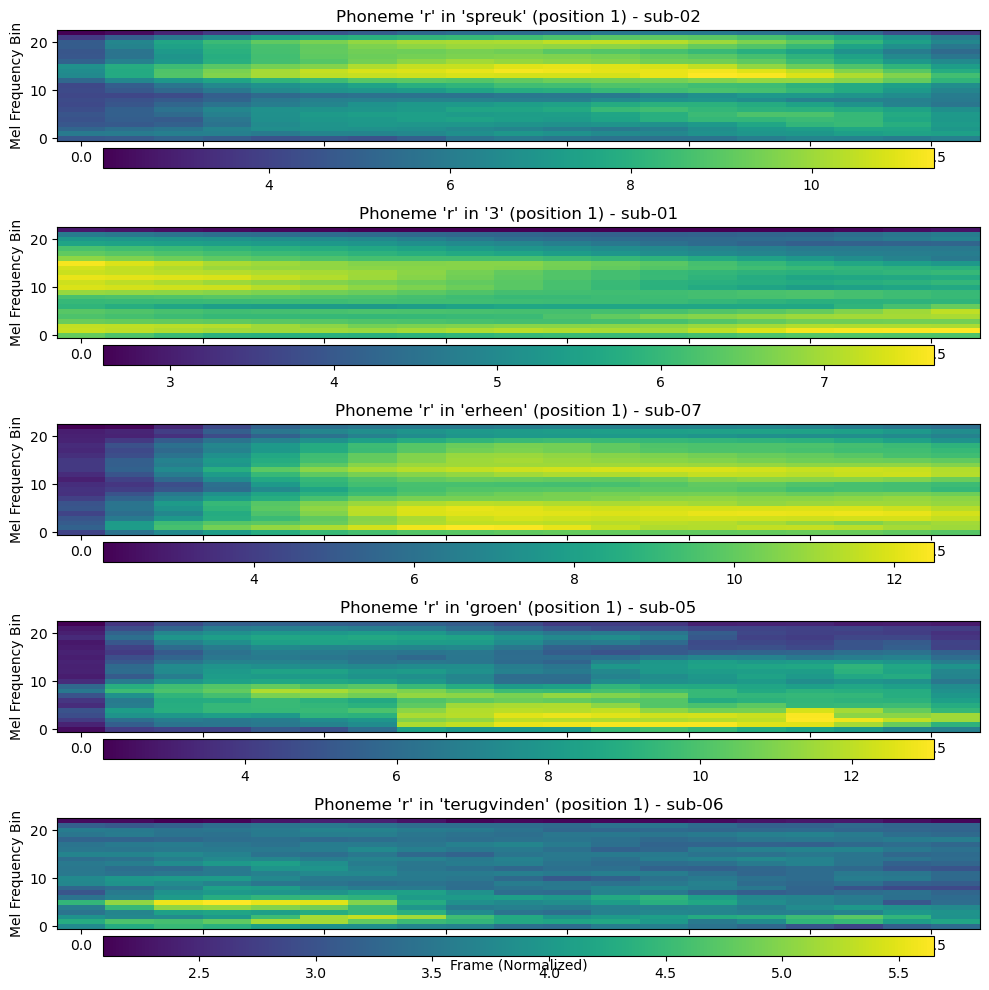

In [15]:
# Extract phoneme segments
df  = train
converted_data = {
    'phoneme_labels': df['phoneme_labels'],
    'phoneme_spectrogram_segments': df['spectrograms'] if df['spectrograms'] is not None else [],
    'phoneme_words': df['phoneme_words'],
    'phoneme_positions': [0] * len(df['phoneme_labels']) if 'phoneme_positions' not in df else df['phoneme_positions'],
    'phoneme_participant_ids': df['phoneme_participant_ids'] if 'phoneme_participant_ids' in df else ['unknown'] * len(df['phoneme_labels'])
}


phoneme_segments = validator.extract_phoneme_segments_from_batch(converted_data)

# Check if we found any phonemes
if phoneme_segments:
    print(f"Found {len(phoneme_segments)} phonemes")
    print("Available phonemes:", list(phoneme_segments.keys()))
    
    # Find the phoneme with the most segments
    most_common_phoneme = max(phoneme_segments.keys(), key=lambda p: len(phoneme_segments[p]))
    print(f"Most common phoneme: '{most_common_phoneme}' with {len(phoneme_segments[most_common_phoneme])} segments")
    
    # Visualize the most common phoneme
    validator.visualize_phoneme_segments(
        phoneme_segments=phoneme_segments,
        phoneme=most_common_phoneme,
        max_examples=5
    )
else:
    print("No phonemes found")

In [16]:
# 2. Try to resolve unknown phonemes
resolved_batch = validator.resolve_unknown_phonemes(converted_data)

# 3. Extract segments from the resolved batch
resolved_segments = validator.extract_phoneme_segments_from_batch(resolved_batch)

# 4. Compare the number of resolved phonemes
print(f"Original segments: {len(phoneme_segments)} phonemes")
print(f"Resolved segments: {len(resolved_segments)} phonemes")

PhonemeValidator [DEBUG]: Attempting to resolve 40 unknown phonemes
PhonemeValidator [DEBUG]: Resolved phoneme at position 0 in 'maantje' as 'm'
PhonemeValidator [DEBUG]: Resolved phoneme at position 0 in 'maantje' as 'm'
PhonemeValidator [DEBUG]: Resolved phoneme at position 0 in 'maantje' as 'm'
PhonemeValidator [DEBUG]: Resolved phoneme at position 0 in 'maantje' as 'm'
PhonemeValidator [DEBUG]: Resolved phoneme at position 0 in 'maantje' as 'm'
PhonemeValidator [DEBUG]: Resolved phoneme at position 0 in 'of' as 'ɔf'
PhonemeValidator [DEBUG]: Resolved phoneme at position 0 in 'of' as 'ɔf'
PhonemeValidator [DEBUG]: Resolved phoneme at position 0 in 'of' as 'ɔf'
PhonemeValidator [DEBUG]: Resolved phoneme at position 0 in 'of' as 'ɔf'
PhonemeValidator [DEBUG]: Resolved phoneme at position 0 in 'of' as 'ɔf'
PhonemeValidator [DEBUG]: Resolved phoneme at position 0 in 'of' as 'ɔf'
PhonemeValidator [DEBUG]: Resolved phoneme at position 0 in 'of' as 'ɔf'
PhonemeValidator [DEBUG]: Resolved p

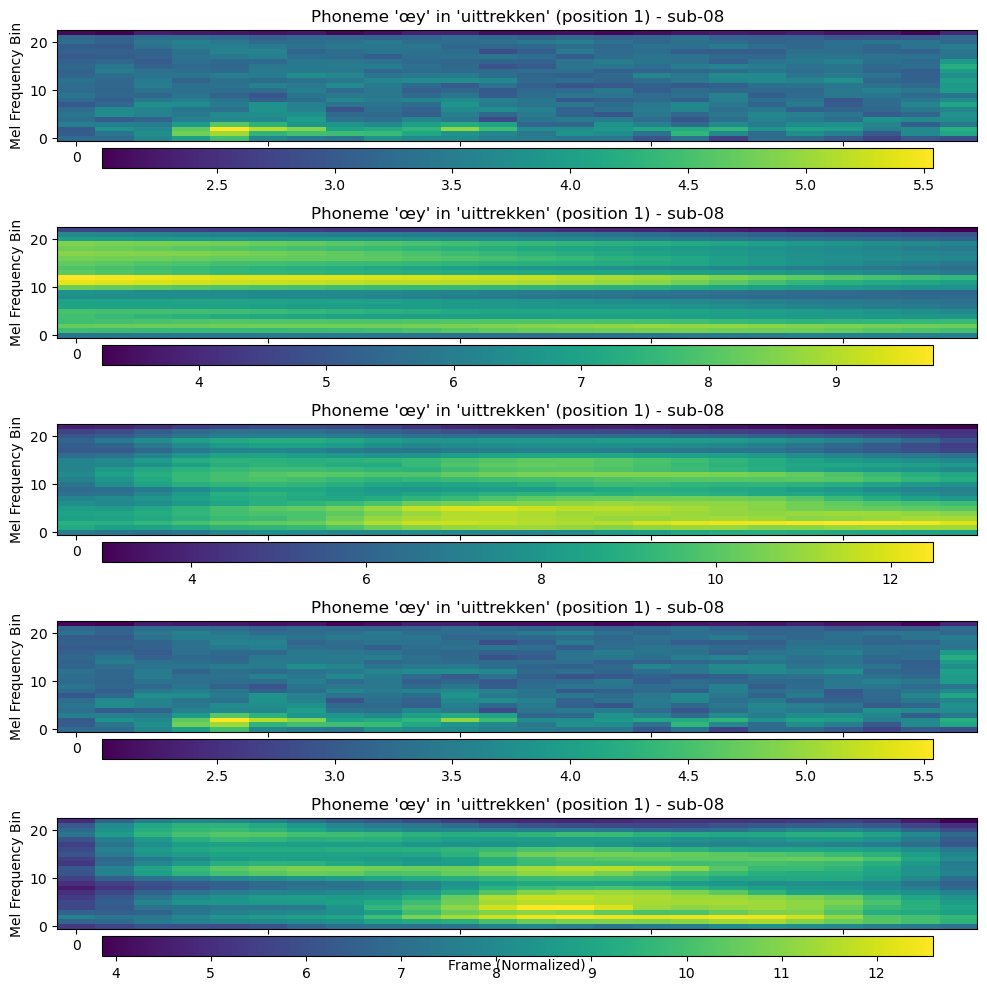

In [17]:
# 5. Visualize a phoneme with proper position display
if resolved_segments:
    top_phoneme = max(resolved_segments.keys(), key=lambda p: len(resolved_segments[p]))
    validator.visualize_phoneme_segments(
        phoneme_segments=resolved_segments,
        phoneme=top_phoneme,
        max_examples=5
    )

In [18]:
def visualize_phoneme_category(phoneme_batch, phoneme_label, max_examples=5):
    """Visualize examples of a specific phoneme"""
    import matplotlib.pyplot as plt
    
    # Find all segments for this phoneme
    indices = [i for i, label in enumerate(phoneme_batch['phoneme_labels']) 
               if label == phoneme_label]
    
    if not indices:
        print(f"No segments found for phoneme '{phoneme_label}'")
        return None
    
    # Limit to max_examples
    if len(indices) > max_examples:
        import random
        indices = random.sample(indices, max_examples)
    
    # Create figure
    fig, axs = plt.subplots(len(indices), 1, figsize=(10, 3*len(indices)))
    if len(indices) == 1:
        axs = [axs]
    
    # Plot each segment
    for i, idx in enumerate(indices):
        segment = phoneme_batch['phoneme_spectrogram_segments'][idx]
        word = phoneme_batch['phoneme_words'][idx]
        position = phoneme_batch['phoneme_positions'][idx]
        
        im = axs[i].imshow(segment.T, aspect='auto', origin='lower', cmap='viridis')
        axs[i].set_title(f"Phoneme '{phoneme_label}' in word '{word}' (position {position})")
        axs[i].set_ylabel('Frequency Bin')
        
        # Only add x-label to bottom plot
        if i == len(indices) - 1:
            axs[i].set_xlabel('Time Frame')
        
        # Add colorbar
        plt.colorbar(im, ax=axs[i])
    
    plt.tight_layout()
    plt.show()
    
    return fig


Visualizing phoneme 'm':


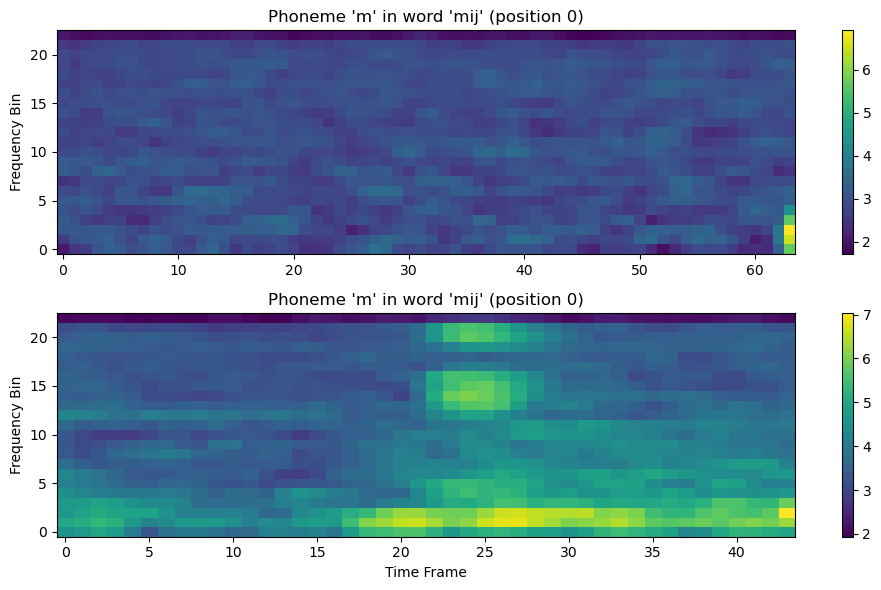


Visualizing phoneme 'ɛ':


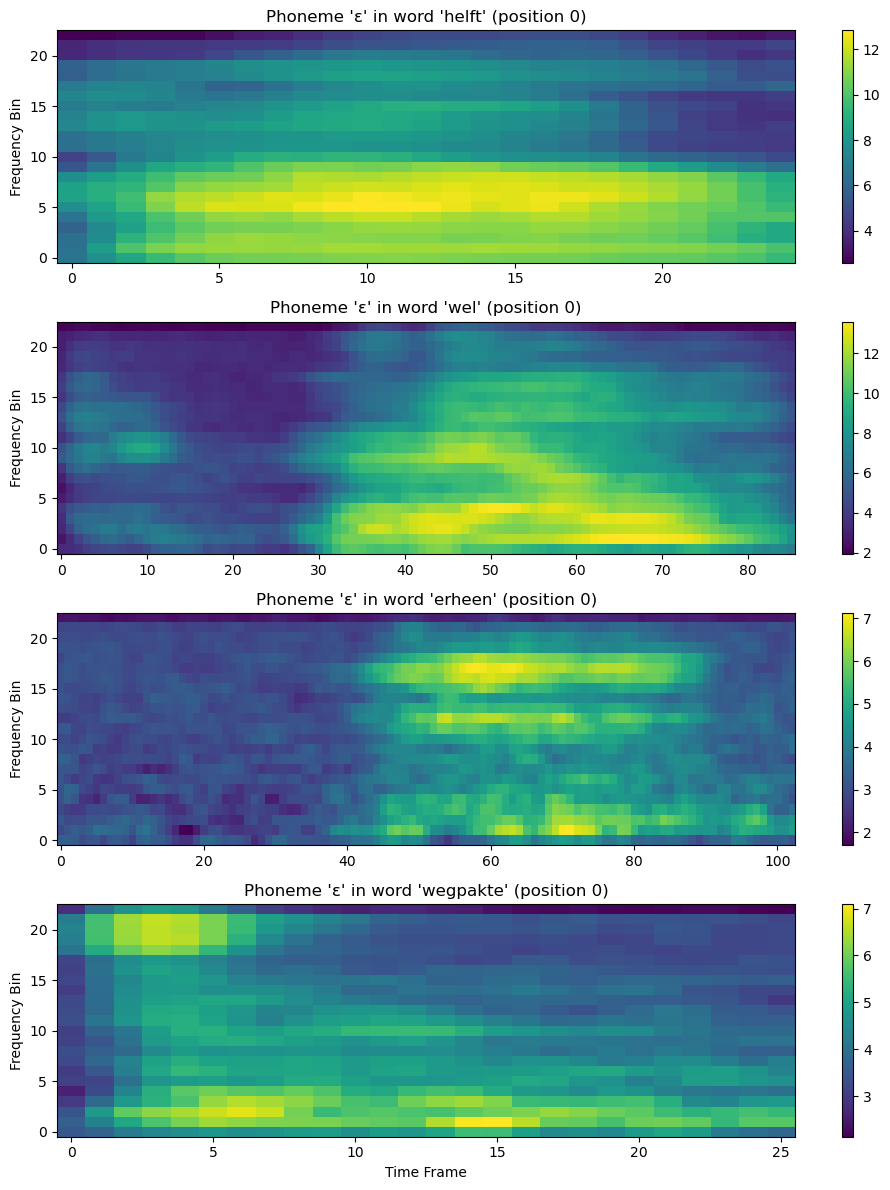


Visualizing phoneme 'œy':
No segments found for phoneme 'œy'

Visualizing phoneme 'n':


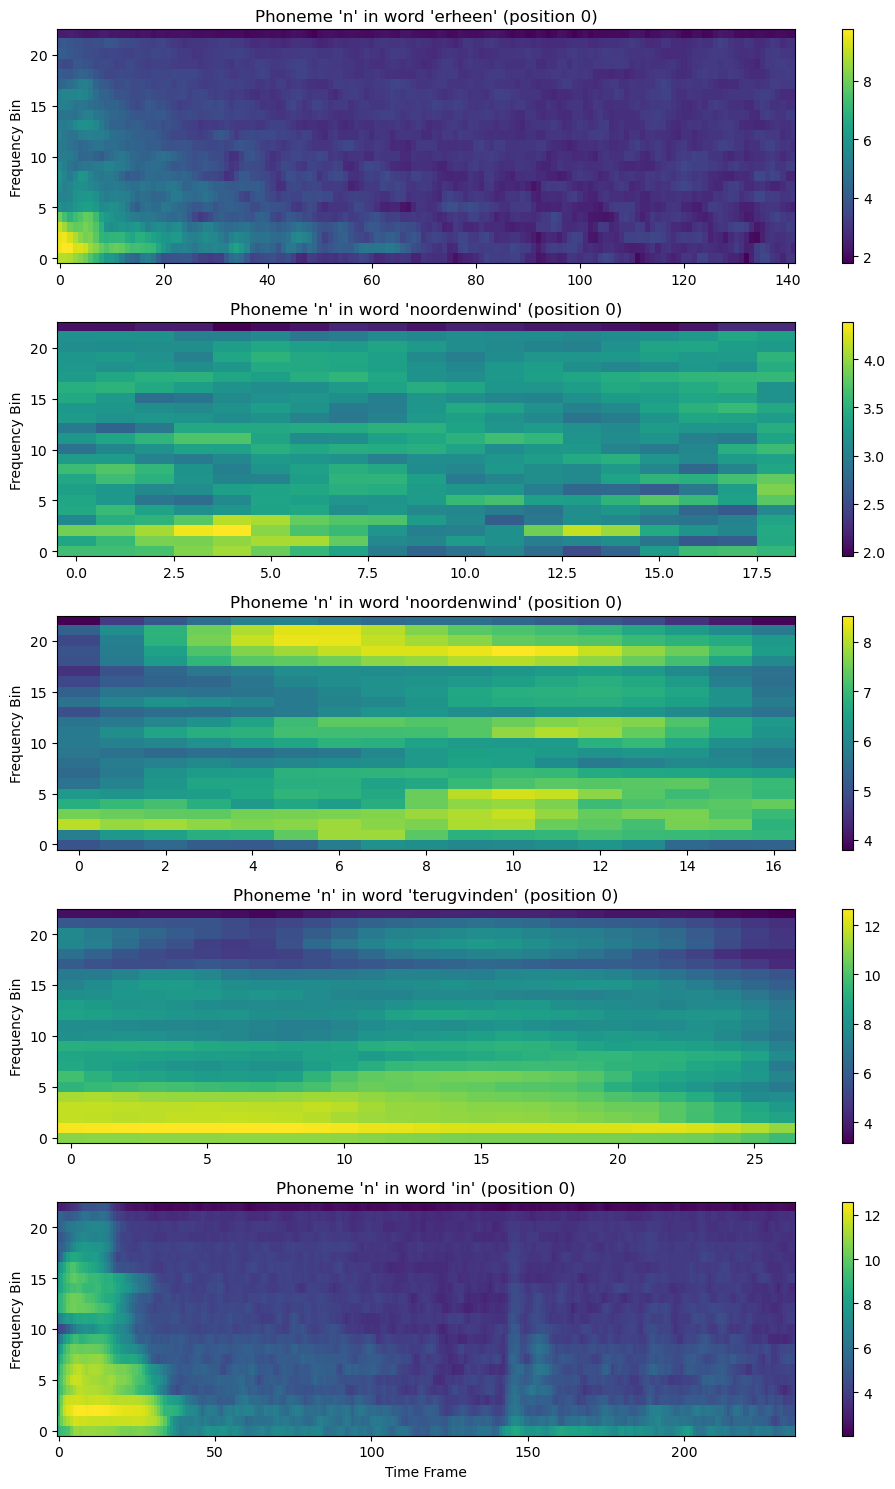


Visualizing phoneme 't':


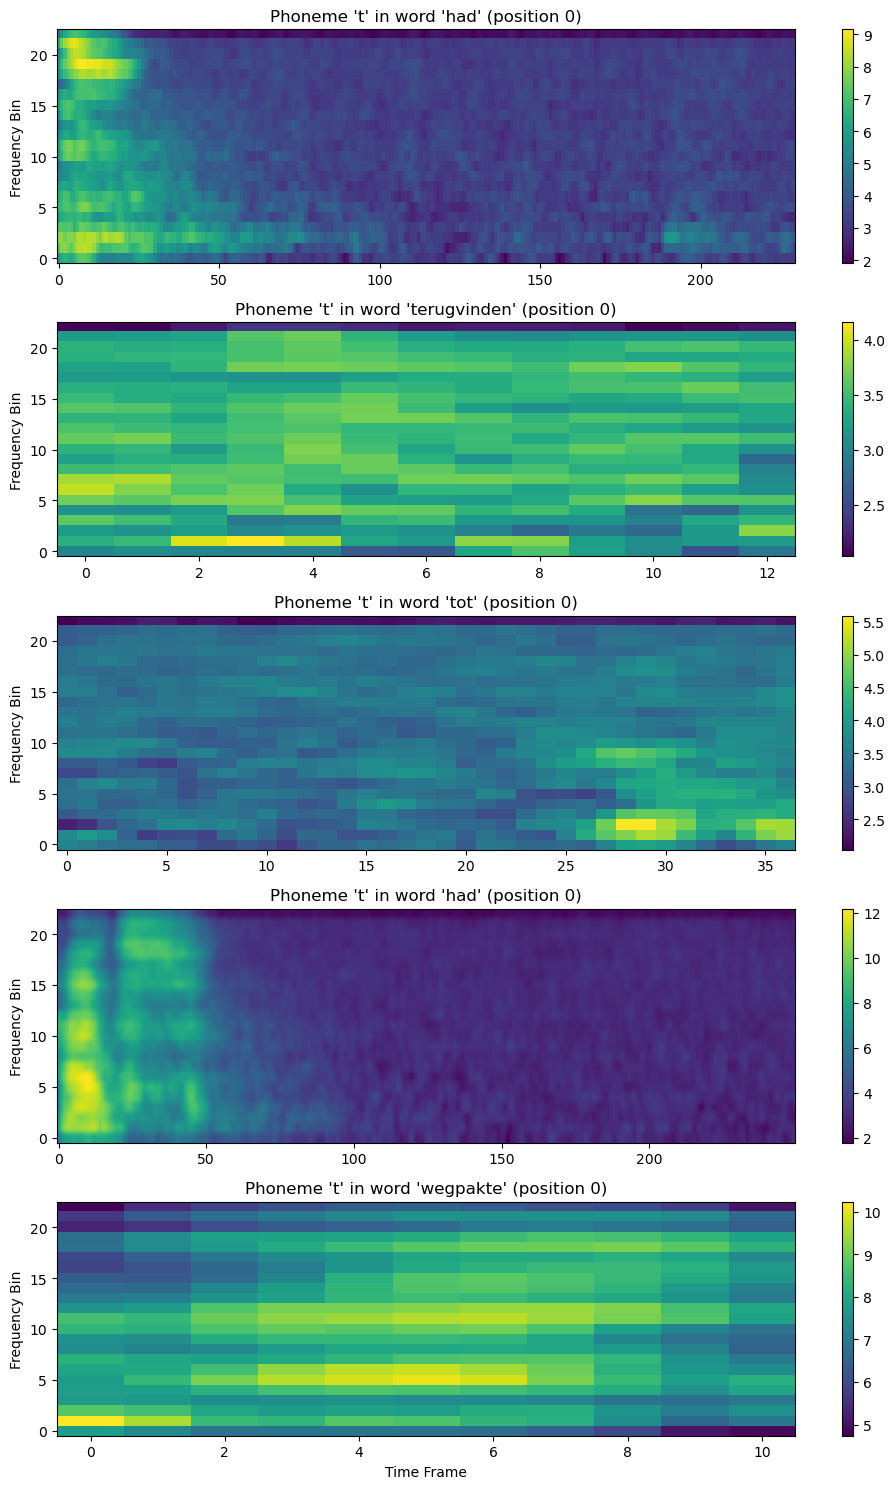

In [19]:
# Visualize a few interesting phonemes
for phoneme in ['m', 'ɛ', 'œy', 'n', 't']:
    print(f"\nVisualizing phoneme '{phoneme}':")
    visualize_phoneme_category(converted_data, phoneme)

In [20]:
# Structure the data correctly for validation
all_results = {}
for i, word in enumerate(converted_data['phoneme_words']):
    if word not in all_results:
        all_results[word] = []
    
    # Create a result entry for this instance
    result = {
        'segments': [converted_data['phoneme_spectrogram_segments'][i]],
        'boundaries': [0, converted_data['phoneme_spectrogram_segments'][i].shape[0]],
        'word': word,
        'participant_id': converted_data['phoneme_participant_ids'][i] if 'phoneme_participant_ids' in converted_data else 'unknown'
    }
    all_results[word].append(result)

# Now validate with properly structured data
validation_results = validator.validate_phoneme_consistency(
    all_results=all_results,
    min_occurrences=2
)
validation_results

{'ɔ': {'count': 6,
  'duration_mean': 100.33333333333333,
  'duration_std': 93.06210590544121,
  'duration_cv': 0.9275292947386168,
  'spectral_similarity': 0.9717063097931259,
  'position_consistency': 1.0,
  'common_words': ['sok', 'tot'],
  'most_common_position': 1},
 'ɛi': {'count': 12,
  'duration_mean': 150.08333333333334,
  'duration_std': 102.94129260030797,
  'duration_cv': 0.6858942316511358,
  'spectral_similarity': 0.9508644594231644,
  'position_consistency': 1.0,
  'common_words': ['bij', 'lij', 'mij', 'zei'],
  'most_common_position': 1},
 'ɛ': {'count': 21,
  'duration_mean': 57.142857142857146,
  'duration_std': 61.29575897260112,
  'duration_cv': 1.0726757820205195,
  'spectral_similarity': 0.9762020136442464,
  'position_consistency': 0.7619047619047619,
  'common_words': ['erheen', 'helft', 'wegpakte', 'wel'],
  'most_common_position': 1},
 'a': {'count': 11,
  'duration_mean': 81.81818181818181,
  'duration_std': 76.98620677145907,
  'duration_cv': 0.9409425272067

In [21]:
# For training data
train_converted = {
    'phoneme_labels': train['phoneme_labels'],
    'phoneme_spectrogram_segments': train.get('spectrograms', []),
    'phoneme_words': train['phoneme_words'],
    'phoneme_positions': train.get('phoneme_positions', [0] * len(train['phoneme_labels'])),
    'phoneme_participant_ids': train.get('phoneme_participant_ids', ['unknown'] * len(train['phoneme_labels']))
}

print(f"Training data before resolution: {train_converted['phoneme_labels'].count('?')} unknown phonemes")
resolved_train = validator.resolve_unknown_phonemes(train_converted)
print(f"Training data after resolution: {resolved_train['phoneme_labels'].count('?')} unknown phonemes")

# Update the training data with resolved phonemes
train['phoneme_labels'] = resolved_train['phoneme_labels']

Training data before resolution: 40 unknown phonemes
PhonemeValidator [DEBUG]: Attempting to resolve 40 unknown phonemes
PhonemeValidator [DEBUG]: Resolved phoneme at position 0 in 'maantje' as 'm'
PhonemeValidator [DEBUG]: Resolved phoneme at position 0 in 'maantje' as 'm'
PhonemeValidator [DEBUG]: Resolved phoneme at position 0 in 'maantje' as 'm'
PhonemeValidator [DEBUG]: Resolved phoneme at position 0 in 'maantje' as 'm'
PhonemeValidator [DEBUG]: Resolved phoneme at position 0 in 'maantje' as 'm'
PhonemeValidator [DEBUG]: Resolved phoneme at position 0 in 'of' as 'ɔf'
PhonemeValidator [DEBUG]: Resolved phoneme at position 0 in 'of' as 'ɔf'
PhonemeValidator [DEBUG]: Resolved phoneme at position 0 in 'of' as 'ɔf'
PhonemeValidator [DEBUG]: Resolved phoneme at position 0 in 'of' as 'ɔf'
PhonemeValidator [DEBUG]: Resolved phoneme at position 0 in 'of' as 'ɔf'
PhonemeValidator [DEBUG]: Resolved phoneme at position 0 in 'of' as 'ɔf'
PhonemeValidator [DEBUG]: Resolved phoneme at position 0

In [22]:
# For test data
test_converted = {
    'phoneme_labels': test['phoneme_labels'],
    'phoneme_spectrogram_segments': test.get('spectrograms', []),
    'phoneme_words': test['phoneme_words'],
    'phoneme_positions': test.get('phoneme_positions', [0] * len(test['phoneme_labels'])),
    'phoneme_participant_ids': test.get('phoneme_participant_ids', ['unknown'] * len(test['phoneme_labels']))
}

print(f"Test data before resolution: {test_converted['phoneme_labels'].count('?')} unknown phonemes")
resolved_test = validator.resolve_unknown_phonemes(test_converted)
print(f"Test data after resolution: {resolved_test['phoneme_labels'].count('?')} unknown phonemes")

# Update the test data with resolved phonemes
test['phoneme_labels'] = resolved_test['phoneme_labels']

Test data before resolution: 11 unknown phonemes
PhonemeValidator [DEBUG]: Attempting to resolve 11 unknown phonemes
PhonemeValidator [DEBUG]: Resolved phoneme at position 0 in 'smeekte' as 's'
PhonemeValidator [DEBUG]: Resolved phoneme at position 0 in 'smeekte' as 's'
PhonemeValidator [DEBUG]: Resolved phoneme at position 0 in 'smeekte' as 's'
PhonemeValidator [DEBUG]: Resolved phoneme at position 0 in 'smeekte' as 's'
PhonemeValidator [DEBUG]: Resolved phoneme at position 0 in 'smeekte' as 's'
PhonemeValidator [DEBUG]: Resolved phoneme at position 0 in 'sterkste' as 's'
PhonemeValidator [DEBUG]: Resolved phoneme at position 0 in 'sterkste' as 's'
PhonemeValidator [DEBUG]: Resolved phoneme at position 0 in 'sterkste' as 's'
PhonemeValidator [DEBUG]: Resolved phoneme at position 0 in 'sterkste' as 's'
PhonemeValidator [DEBUG]: Resolved phoneme at position 0 in 'sterkste' as 's'
PhonemeValidator [DEBUG]: Resolved phoneme at position 0 in 'sterkste' as 's'
PhonemeValidator [DEBUG]: Reso

In [23]:
# Prepare the input features (EEG segments) and target labels (phonemes)
# train_features = train['features']
# train_labels = train['phoneme_labels']
# test_features = test['features']
# test_labels = test['phoneme_labels']

In [24]:
# This neural network model will learn to map EEG signals to phonemes
phoneme_model = PhonemeDecoderModel(
    model_type='lstm_cnn',
    output_dir=os.path.join(path_results, 'phoneme_model'),
    debug_mode=True
)

PhonemeDecoderModel: Initialized with DEBUG_MODE=True
PhonemeDecoderModel: Initialized PhonemeDecoderModel with model_type=lstm_cnn


PhonemeDecoderModel: Training model with accumulated phoneme data
PhonemeDecoderModel: Training data: 160 samples, 35 unique phonemes
PhonemeDecoderModel: Found 96 test samples with 29 unique phonemes
PhonemeDecoderModel: Warning: Test set contains 5 phonemes not in training set: ['sx', 'tʋ', 'ŋ', 'ɪx', 'ʋɑ']
PhonemeDecoderModel: Filtering test samples with unseen phonemes
PhonemeDecoderModel: Filtered test set now has 89 samples
PhonemeDecoderModel: Using 35 unique phoneme classes
PhonemeDecoderModel [DEBUG]: Phoneme classes: ['a' 'aː' 'b' 'd' 'eː' 'f' 'h' 'i' 'k' 'l' 'm' 'n' 'oː' 'p' 'r' 's' 't'
 'uː' 'v' 'x' 'z' 'øː' 'œy' 'ɑ' 'ɔ' 'ɔf' 'ə' 'ɛ' 'ɛi' 'ɣ' 'ɪ' 'ʋ' 'ʋɪ' 'ʏ'
 'ˌ']
PhonemeDecoderModel: Warning: Found 4 phoneme classes with only 1 sample:
PhonemeDecoderModel:   - Phoneme 'b' has only 1 sample
PhonemeDecoderModel:   - Phoneme 'uː' has only 1 sample
PhonemeDecoderModel:   - Phoneme 'z' has only 1 sample
PhonemeDecoderModel:   - Phoneme 'ʋɪ' has only 1 sample
PhonemeDecoderMode

C:\Users\irina\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                      │ (None, 296, 64)             │           9,664 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 296, 64)             │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d (MaxPooling1D)         │ (None, 148, 64)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_1 (Conv1D)                    │ (None, 148, 128)            │          24,704 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 148, 128)            │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d_1 (MaxPooling1D)       │ (None, 74, 128)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional (Bidirectional)        │ (None, 74, 200)             │         183,200 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 74, 200)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional_1 (Bidirectional)      │ (None, 100)                 │         100,400 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 100)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │          12,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 128)                 │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 35)                  │           4,515 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 336,691 (1.28 MB)

 Trainable params: 336,051 (1.28 MB)

 Non-trainable params: 640 (2.50 KB)

PhonemeDecoderModel: Training model with validation data for up to 50 epochs
Epoch 1/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 8s 340ms/step - accuracy: 0.0177 - loss: 4.5185 - val_accuracy: 0.0000e+00 - val_loss: 3.5929 - learning_rate: 0.0010
Epoch 2/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step - accuracy: 0.0802 - loss: 3.5561 - val_accuracy: 0.0000e+00 - val_loss: 3.5839 - learning_rate: 0.0010
Epoch 3/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - accuracy: 0.1646 - loss: 3.2615 - val_accuracy: 0.0000e+00 - val_loss: 3.5801 - learning_rate: 0.0010
Epoch 4/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - accuracy: 0.2562 - loss: 2.7980 - val_accuracy: 0.0625 - val_loss: 3.5762 - learning_rate: 0.0010
Epoch 5/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.3729 - loss: 2.3946 - val_accuracy: 0.0625 - val_loss: 3.5769 - learning_rate: 0.0010
Epoch 6/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 0.4760 - loss: 1.9060 - val_accuracy: 0.0312 - val_loss: 3.5836 - learning_rate: 0.0010
Epoch 7/50
4/4 ━

C:\Users\irina\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\irina\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\irina\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


PhonemeDecoderModel: Training history plot saved to ./results\phoneme_model\training_history.png


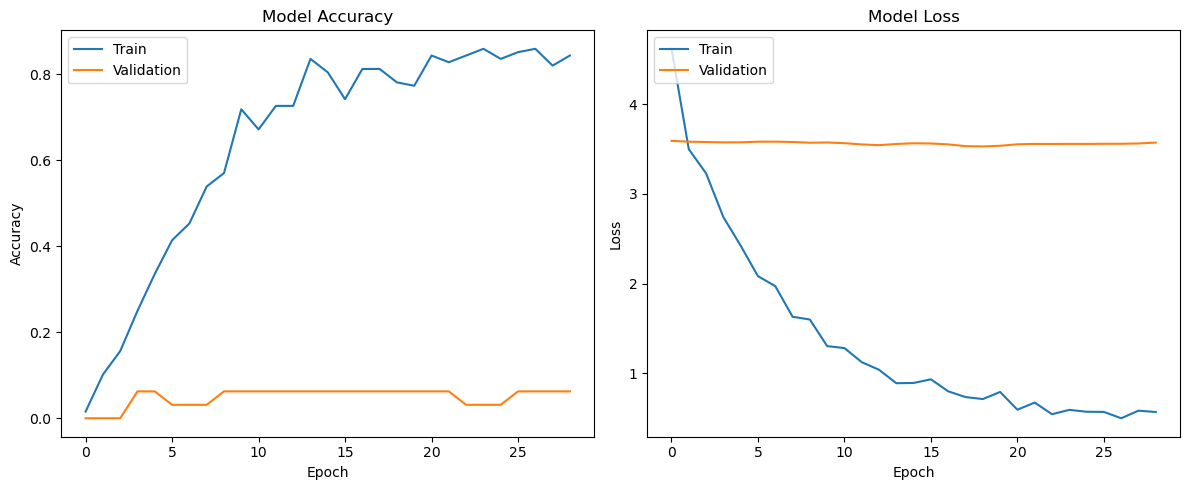

In [25]:
# This handles all preprocessing, training, and evaluation in a single call
results = phoneme_model.train_with_accumulated_data(
    train_accumulated_data=train,  # Training data
    test_accumulated_data=test,    # Test data
    epochs=50,                                      # Maximum training epochs
    batch_size=32,                                  # Batch size for training
    patience=10,                                     # Early stopping patience
    handle_unseen_phonemes='filter',
    resolve_unknown=True
)

In [26]:
# Step 13: Evaluate model performance
evaluation = results['evaluation']
print(f"Phoneme model accuracy: {evaluation['accuracy']:.4f}")

Phoneme model accuracy: 0.0225


In [27]:
# Step 14: Compare with baseline (optional)
# Evaluate the baseline BrainAudioDecoder for comparison
baseline_decoder = BrainAudioDecoder(
    path_bids=path_bids,
    path_output=path_output,
    path_results=path_results
)
baseline_results = baseline_decoder.train_test_model(
    participant_id='sub-08',  # Choose a representative participant
    save_audio=False          # Don't save audio reconstructions
)
baseline_accuracy = np.mean(baseline_results['correlations'])
print(f"Baseline model correlation: {baseline_accuracy:.4f}")

Training and testing model for sub-08...
sub-08 has mean correlation of 0.7152
Baseline model correlation: 0.7152


PhonemeDecoderModel: Confusion matrix plot saved to ./results\phoneme_model\confusion_matrix.png


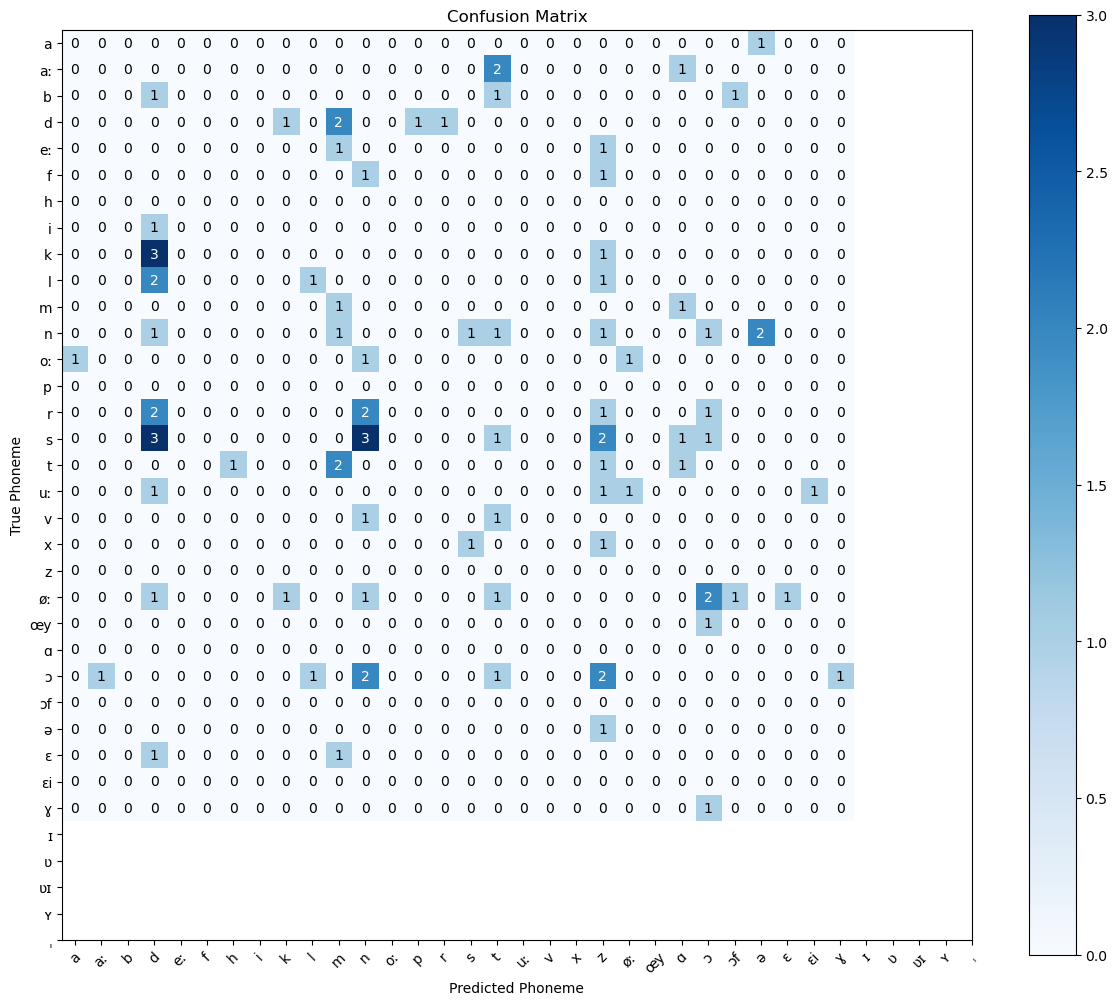

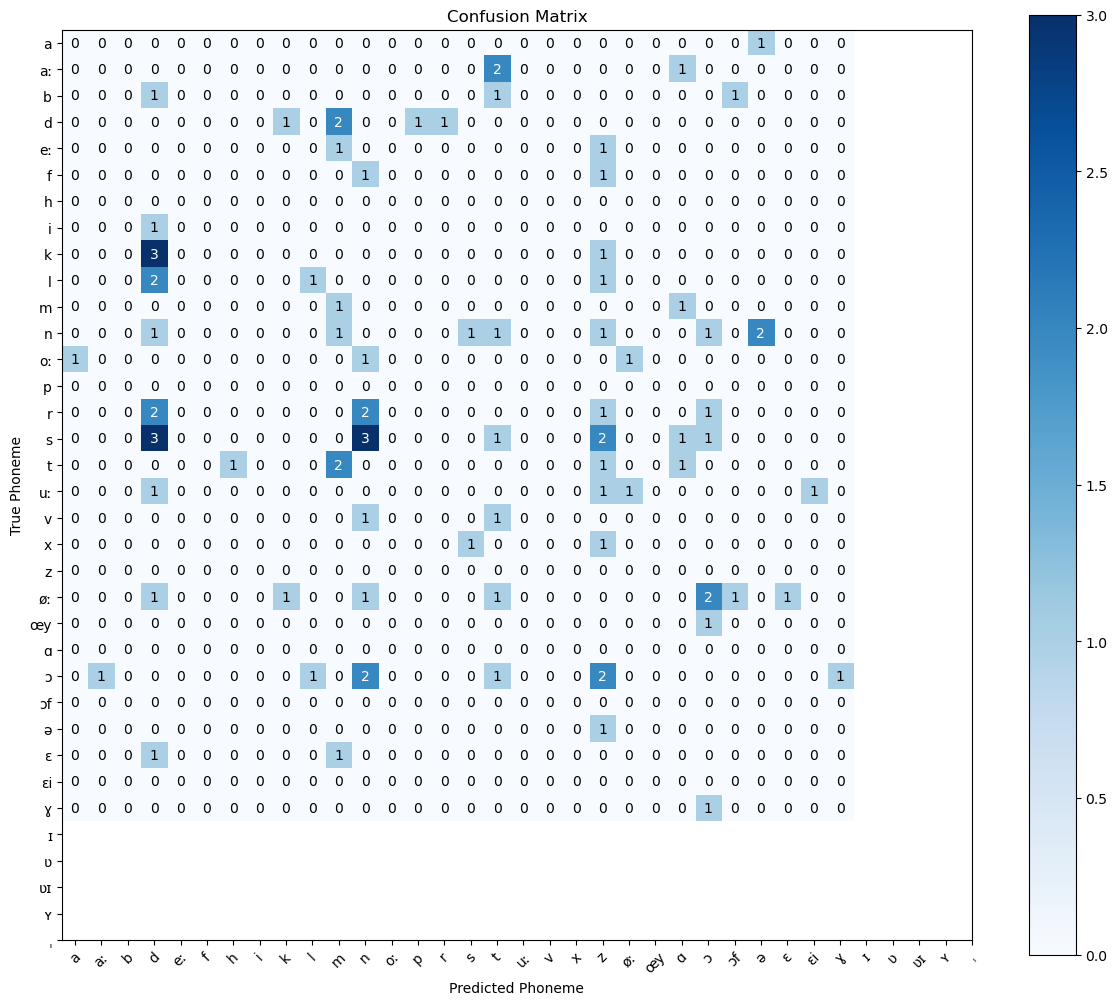

In [28]:
phoneme_model.plot_confusion_matrix(results['evaluation']['confusion_matrix'])

PhonemeDecoderModel: Training history plot saved to ./results\phoneme_model\training_history.png


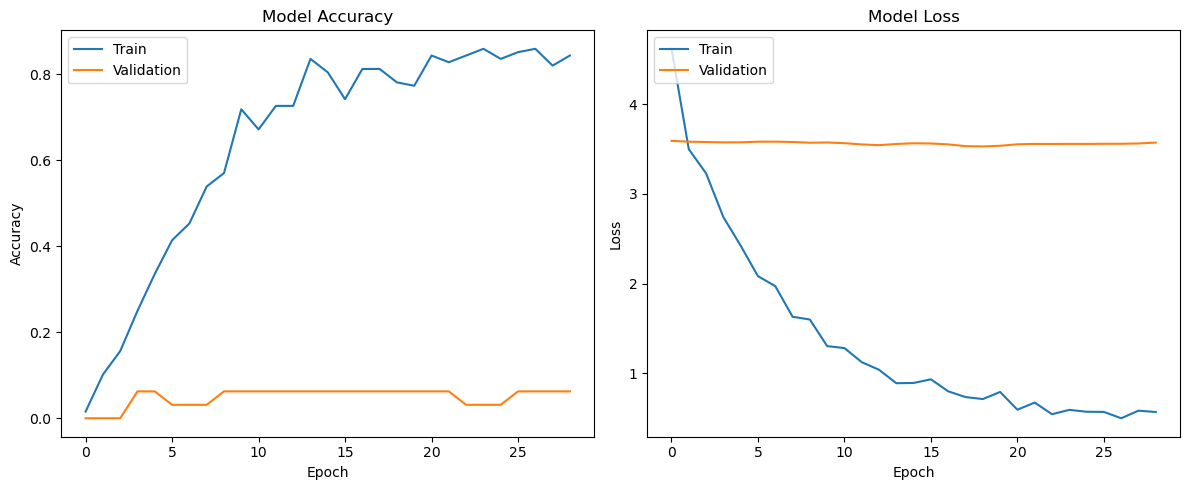

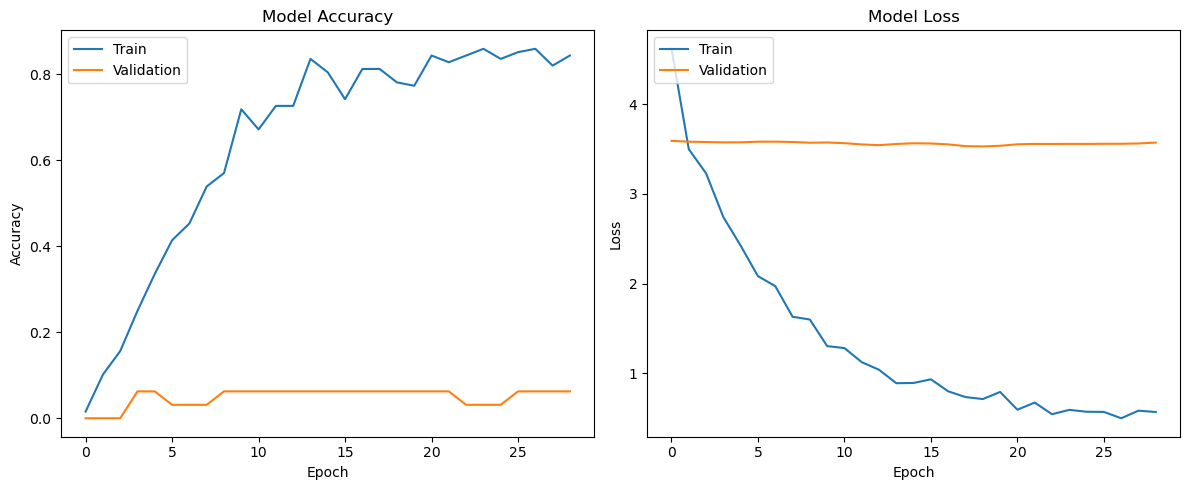

In [29]:
# Step 15: Generate visualizations (optional)
# Create plots comparing model performance, confusion matrices, etc.
phoneme_model.plot_training_history()